In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import subprocess
from enum import IntEnum, auto
from pathlib import Path

from FluctuationAnalysis import fluc
from Cascades import casc
from Settings import Settings, Setting

In [ ]:
#run = fluc.run_simulation()
# energy, spin_array = fluc.get_level_arrays(fluc.get_level_data(run))
# fa = fluc.fluctuation_analysis(energy, spin_array[5])
# fluc.plot_fluctuation_analysis(energy, fa, std_path)

0.5


In [ ]:
with open(Settings.std_path / "run.txt", "w") as f:
    f.write(run)

In [6]:
with open(Settings.std_path / "run.txt", "r") as f:
    run = f.read()

In [5]:
energy, bin_counter = casc.from_cascades_get_binned_events()

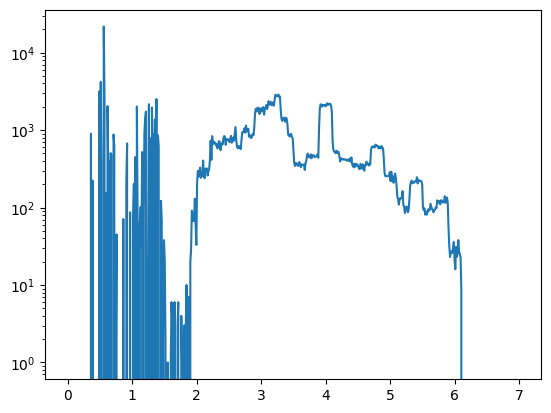

In [9]:
plt.plot(energy, bin_counter)
plt.yscale("log")
plt.savefig(Settings.std_path / "MyTestNumber3.png", dpi = 300)

In [6]:
fa = fluc.fluctuation_analysis(energy, bin_counter)
fluc.plot_fluctuation_analysis(energy, fa, file_name="Beta1")

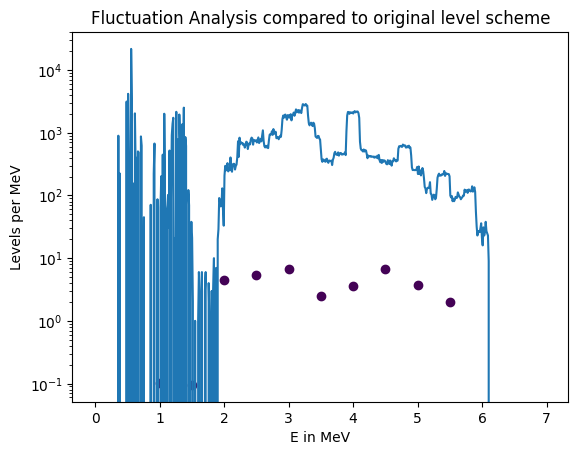

In [7]:
fluc.plot_comparison(fa["fin_energy_int"],fa["fa_dens"],energy,bin_counter,Settings.std_path,"BetaComp1", new_figure=False)

In [9]:
def generate_event_count_slider_plots(ev_start, ev_step, ev_end, *, bin = settings[Setting.g_nConEBin]):
    event_count0 = settings[Setting.g_nEvent]
    global run
    run0 = run
    energy, bin_counter = ([],[])
    print(np.arange(ev_start, ev_end, ev_step))
    for k in np.arange(ev_start, ev_end, ev_step):
        print()
        settings[Setting.g_nEvent] = int(np.floor(k))
        print("start sim")
        run = run_simulation()
        print("end sim")
        energy, bin_counter = from_cascades_get_binned_events(bin)
        plt.figure()
        plt.plot(energy, bin_counter)
        plt.yscale("log")
        plt.savefig(std_path / "events" / str(int(np.floor(k))), dpi = 300)
    run = run0
    settings[Setting.g_nEvent] = event_count0
    return energy, bin_counter

[100000]

start sim
const int g_nReal = 1
const int g_nZ = 32
const int g_nAMass = 76
(changed) const int g_nConEBin = 600
(changed) const int g_nEvent = 100000
end sim


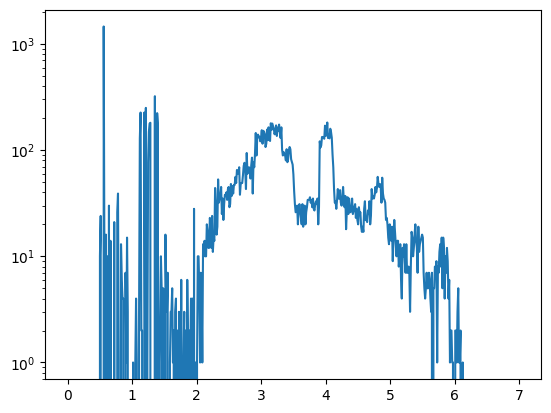

In [32]:
energy, bin_counter = generate_event_count_slider_plots(100000, 1, 100001)
